ConvNeXt Standalone Model

In [1]:
!pip install colorama

In [2]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json





Saving kaggle.json to kaggle.json


In [3]:
!kaggle datasets download -d viswachaitanyasai/deepfake-dataset
!unzip deepfake-dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3505.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3506.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3507.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3508.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3509.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3510.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3511.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3512.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3513.jpg  
  inflating: /content/dataset/deepfake_dataset/validation/ffpp/fake/validation_3514.jpg  
  inflating: /content/dataset/deepfake_dataset/va

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
import timm
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import logging

from albumentations import (
    HorizontalFlip, VerticalFlip, Affine, CLAHE,
    RandomRotate90, Transpose, HueSaturationValue, GaussNoise,
    Sharpen, Emboss, RandomBrightnessContrast, OneOf, Compose, RandomCrop
)
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve



seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

##############################################
#         Advanced Data Augmentation         #
##############################################


def strong_aug(p=0.5):
    return Compose([
        RandomRotate90(p=0.2),
        Transpose(p=0.2),
        HorizontalFlip(p=0.5),
        VerticalFlip(p=0.5),
        OneOf([GaussNoise()], p=0.2),
        Affine(rotate=(-45, 45), scale=(0.9, 1.1), translate_percent=(0.0, 0.1), p=0.2),
        OneOf([
            CLAHE(clip_limit=2),
            Sharpen(),
            Emboss(),
            RandomBrightnessContrast(),
        ], p=0.2),
        HueSaturationValue(p=0.2),
        RandomCrop(width=200, height=200, p=0.3),
    ], p=p)

def augment(aug, image):
    return aug(image=image)["image"]

class Aug(object):
    def __call__(self, img):
        aug = strong_aug(p=0.9)
        img_np = np.array(img)
        augmented = augment(aug, img_np)
        return Image.fromarray(augmented)

##############################################
#            Data Transforms                 #
##############################################
def get_transforms():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return {
        "train": transforms.Compose([
            Aug(),
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.2)
        ]),
        "valid": transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        "test": transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }

data_transforms = get_transforms()

##############################################
#            Dataset Loading                 #
##############################################
base_dataset_dir = "/content/dataset/deepfake_dataset"
sub_datasets = ["celebdf", "dfdc", "ffpp", "realfake"]

train_datasets = []
val_datasets = []
test_datasets = []

for sub in sub_datasets:
    train_path = os.path.join(base_dataset_dir, "train", sub)
    val_path   = os.path.join(base_dataset_dir, "validation", sub)
    test_path  = os.path.join(base_dataset_dir, "test", sub)

    train_datasets.append(datasets.ImageFolder(train_path, transform=data_transforms["train"]))
    val_datasets.append(datasets.ImageFolder(val_path, transform=data_transforms["valid"]))
    test_datasets.append(datasets.ImageFolder(test_path, transform=data_transforms["test"]))

full_train_dataset = ConcatDataset(train_datasets)
full_val_dataset   = ConcatDataset(val_datasets)
full_test_dataset  = ConcatDataset(test_datasets)

train_subset_size = 20000
val_subset_size = 5000
train_indices = random.sample(range(len(full_train_dataset)), train_subset_size)
val_indices = random.sample(range(len(full_val_dataset)), val_subset_size)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset   = Subset(full_val_dataset, val_indices)
test_dataset  = full_test_dataset

batch_size = 16
num_workers = 2

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

##############################################
#        Simple ConvNeXt Detector Model      #
##############################################
class SimpleConvNextDetector(nn.Module):
    def __init__(self, num_classes=1):
        super(SimpleConvNextDetector, self).__init__()
        self.backbone = timm.create_model('convnext_base', pretrained=True, num_classes=0)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.classifier(features)
        return out

model = SimpleConvNextDetector(num_classes=1)
model = model.to(device)
print("Simple ConvNeXt Detector created.")

##############################################
#        Optimizer & Loss Setup              #
##############################################
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

##############################################
#            Training & Validation           #
##############################################
num_epochs = 15

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).int()
        train_correct += (preds.cpu() == labels.cpu().int()).sum().item()
        train_total += labels.size(0)
    train_loss = running_loss / train_total
    train_acc = train_correct / train_total

    # Validation
    model.eval()
    running_loss = 0.0
    val_correct = 0
    val_total = 0
    for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).int()
        val_correct += (preds.cpu() == labels.cpu().int()).sum().item()
        val_total += labels.size(0)
    val_loss = running_loss / val_total
    val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")



Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Simple ConvNeXt Detector created.


Epoch 1/15 - Validation: 100%|██████████| 313/313 [00:57<00:00,  5.47it/s]


...

Epoch [13/15] - Train Loss: 0.1878, Train Acc: 0.9187 | Val Loss: 0.2011, Val Acc: 0.9284


Epoch 14/15 - Validation: 100%|██████████| 313/313 [00:57<00:00,  5.46it/s]


Epoch [14/15] - Train Loss: 0.1734, Train Acc: 0.9277 | Val Loss: 0.2084, Val Acc: 0.9240


Epoch 15/15 - Validation: 100%|██████████| 313/313 [00:57<00:00,  5.46it/s]

Epoch [15/15] - Train Loss: 0.1712, Train Acc: 0.9260 | Val Loss: 0.2340, Val Acc: 0.9212


In [5]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()


Testing: 100%|██████████| 522/522 [00:34<00:00, 15.30it/s]


Test Loss: 0.2456
Test Accuracy: 0.9199
Confusion Matrix:
[[4214  256]
 [ 412 3462]]
ROC AUC Score: 0.9798


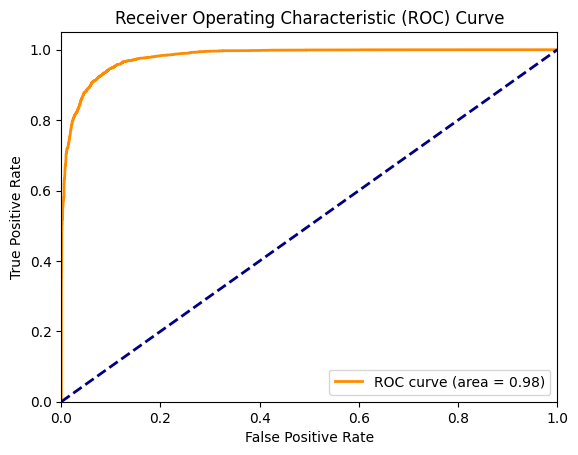

In [ ]:
import torch
from torch.amp import autocast
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

model.eval()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

all_labels = []
all_outputs = []
running_loss = 0.0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        with autocast('cuda'):
            outputs = model(images)

        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)

        all_labels.append(labels.cpu())
        all_outputs.append(outputs.cpu())

all_labels = torch.cat(all_labels).numpy()
all_outputs = torch.cat(all_outputs).numpy()

test_loss = running_loss / len(test_dataset)

preds = (torch.sigmoid(torch.tensor(all_outputs)) > 0.5).int().numpy()

cm = confusion_matrix(all_labels, preds)
accuracy = np.mean((preds == all_labels).astype(np.float32))

roc_auc = roc_auc_score(all_labels, all_outputs)
fpr, tpr, _ = roc_curve(all_labels, all_outputs)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(cm)
print(f"ROC AUC Score: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
